# GSIN vs UPC: what lot-level scan data actually buys the filter

**Question.** GSIN (lot-resolved scanning) should give the particle filter strictly more
information than UPC (aggregate totals). It was doing the opposite: more diffuse beliefs
and large phantom inventory. Why, and what does GSIN buy once that is fixed?

**Setup.** For each seed, one physics episode is simulated under a fixed exogenous order
script, so *every* observation channel sees the identical ground truth (common random
numbers). The richest day log is then replayed through each `ObsMask`, and the resulting
belief is compared with truth.

| Rung | `code_type` | `scan_waste` | `delivery_history` |
|------|-------------|--------------|--------------------|
| P0 | upc | off | none |
| P1 | upc | on | none |
| F1 | **gsin** | on | none |
| F2a | upc | on | pack date |
| F2 | **gsin** | on | pack date |
| F3 | **gsin** | on | temperature trace |

`P1 → F1` and `F2a → F2` are the clean UPC↔GSIN contrasts: same waste and delivery
channels, only the code type changes.

**Data.** `experiments/data/*.json`, produced by
`cargo run -p voi_core --release --example gsin_upc_diag`. Four code epochs are on disk:

| File | Epoch | Spoilage model |
|------|-------|----------------|
| `gsin_upc_before.json` | T-137, pre-ADR-0137 | binomial waste; GSIN likelihood degenerate (the bug) |
| `gsin_upc_pre_t141.json` | ADR 0137 | shared-δ interval constraint |
| `gsin_upc_t140.json` | T-140 / ADR 0141 | shared-δ interval, unified gamma **arrival** |
| `gsin_upc_after.json` | T-141 / ADR 0143 | **independent per-unit aging** + Poisson-binomial |

> **T-150 recal pending.** The committed `gsin_upc_after.json` / `voi_profits_after.json`
> side still reflects pre–ADR-0144 arrival physics. After corridor plumbing and RNG stream
> fixes merge, regenerate the after side and add a T-150 / ADR 0144 row to the epoch ladder.

Regenerate the after side with `experiments/regen_gsin_upc_data.sh` (belief metrics) and
`experiments/regen_voi_profits.py` (§4 closed loop). Use `experiments/regen_tuned_alpha.py`
for the production α table (`rollout` inherits `sw`; not independently tuned).

Two provenance corrections worth stating, because they change how the columns read:

1. `gsin_upc_pre_t141.json` is **not** a run of the T-140 parent harness — it is a
   byte-identical copy of the ADR 0137-era file (18 rows, three regimes, no thermal
   fixture). The true T-140 baseline is `gsin_upc_t140.json`, regenerated at that tip.
2. > **Harness note.** The T-138 rewrite of `gsin_upc_diag` reintroduced, in the
   > *measurement* code, the same fixed-`units_per_lot` partition that ADR 0137 removed from
   > the filter, and read ESS back off `bank.weights` *after* the step's resample — where
   > they are uniform by construction. **Per-lot MAE and ESS are meaningless in any
   > regeneration between T-138 and this one**, the shipped T-141 verify regen included.
   > Both now read the bank's observed `lot_offsets` and the filter's own pre-resample
   > `StepDiagnostics.ess`.

The diag harness runs four fleet regimes; the two oldest files predate the thermal fixture
and carry three, so before/after panels are restricted to the shared set.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

DATA = Path("..") / "experiments" / "data"
if not DATA.exists():  # notebook executed from the repo root
    DATA = Path("experiments") / "data"

before = json.loads((DATA / "gsin_upc_before.json").read_text())
after = json.loads((DATA / "gsin_upc_after.json").read_text())
adr0137 = json.loads((DATA / "gsin_upc_pre_t141.json").read_text())
t140 = json.loads((DATA / "gsin_upc_t140.json").read_text())

# The epoch ladder, oldest first. Labels are what §6 charts.
EPOCHS = {
    "T-137\npre-0137": before,
    "ADR 0137\nshared δ": adr0137,
    "T-140\nADR 0141": t140,
    "T-141\nADR 0143": after,
}
voi_before = json.loads((DATA / "voi_profits_before.json").read_text())
voi_after = json.loads((DATA / "voi_profits_after.json").read_text())

RUNGS = ["P0", "P1", "F1", "F2a", "F2", "F3"]
GSIN = {"F1", "F2", "F3"}
REGIMES = list(dict.fromkeys(r["regime"] for r in after))

# Regimes are addressed by name, never by position. The two oldest epochs predate the
# thermal fixture, so the files no longer carry the same regime list, and a positional
# index would silently retarget every figure the moment one is added.
HOMOG = "Homogeneous fleet, overlapping lots"
HET = "Heterogeneous fleet, overlapping lots"
DEEP = "Heterogeneous fleet, deep shelf"
THERMAL = "Thermal fleet, overlapping lots"

BEFORE_REGIMES = set(r["regime"] for r in before)
SHARED = [r for r in REGIMES if r in BEFORE_REGIMES]  # before/after comparable

# Categorical slots 1-3 of the validated default palette (all-pairs clean, light mode).
C_BEFORE, C_AFTER, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, INK_3 = "#0b0b0b", "#52514e", "#8a8985"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": INK_3,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "font.size": 10,
    "figure.dpi": 120,
})


def pick(rows, regime):
    """Rows for one regime, keyed by rung."""
    return {r["channel"]: r for r in rows if r["regime"] == regime}


def grouped_bars(ax, labels, series, colors, fmt="{:.2f}", ylabel="", legend=True,
                 label_size=7.5, stagger=0.0):
    """Grouped bars with a surface gap and a direct label on every bar.

    Labels are mandatory rather than decorative: two palette slots sit below 3:1
    contrast on this surface, so identity must not rest on colour alone.
    """
    n = len(series)
    x = np.arange(len(labels))
    width = 0.8 / n
    for i, ((name, vals), color) in enumerate(zip(series.items(), colors)):
        off = (i - (n - 1) / 2) * width
        bars = ax.bar(x + off, vals, width * 0.92, label=name, color=color,
                      edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
        for b, v in zip(bars, vals):
            above = v >= 0
            dy = (4 if above else -11) + (stagger if i % 2 else 0.0) * (1 if above else -1)
            ax.annotate(fmt.format(v),
                        (b.get_x() + b.get_width() / 2, b.get_height()),
                        textcoords="offset points", xytext=(0, dy),
                        ha="center", fontsize=label_size, color=INK_2)
    ax.set_xticks(x, labels)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.margins(y=0.20)
    if n > 1 and legend:
        ax.legend(frameon=False, fontsize=9, loc="upper left")


print(f"{len(REGIMES)} regimes:")
for r in REGIMES:
    print(" -", r, "" if r in BEFORE_REGIMES else "(T-140 onward)")
print()
for name, rows in EPOCHS.items():
    print(f"{name.replace(chr(10), ' '):<22} {len(rows):>3} rows")

4 regimes:
 - Homogeneous fleet, overlapping lots 
 - Heterogeneous fleet, overlapping lots 
 - Heterogeneous fleet, deep shelf 
 - Thermal fleet, overlapping lots (T-140 onward)

T-137 pre-0137          18 rows
ADR 0137 shared δ       18 rows
T-140 ADR 0141          24 rows
T-141 ADR 0143          24 rows


## 1. The defect: GSIN believed in inventory that was not there

`count_bias` is the mean signed error of the belief's expected live-unit count against
truth, averaged over days after burn-in. Positive means the filter thinks the shelf holds
more than it does.

Before the fix, the GSIN rungs carried **+24 to +25 units** of phantom mass. The mechanism
was not statistical: the filter partitioned each particle row into fixed `units_per_lot`
chunks while truth appends one variable-width segment per delivery. Once those partitions
diverged, `waste_by.len() != n_lots` made the lot-resolved likelihood return `-inf` for
every particle, the weights normalised to uniform, and GSIN ran as a blind bootstrap
filter — with a fixed-width drain on each arrival inflating the row every delivery.

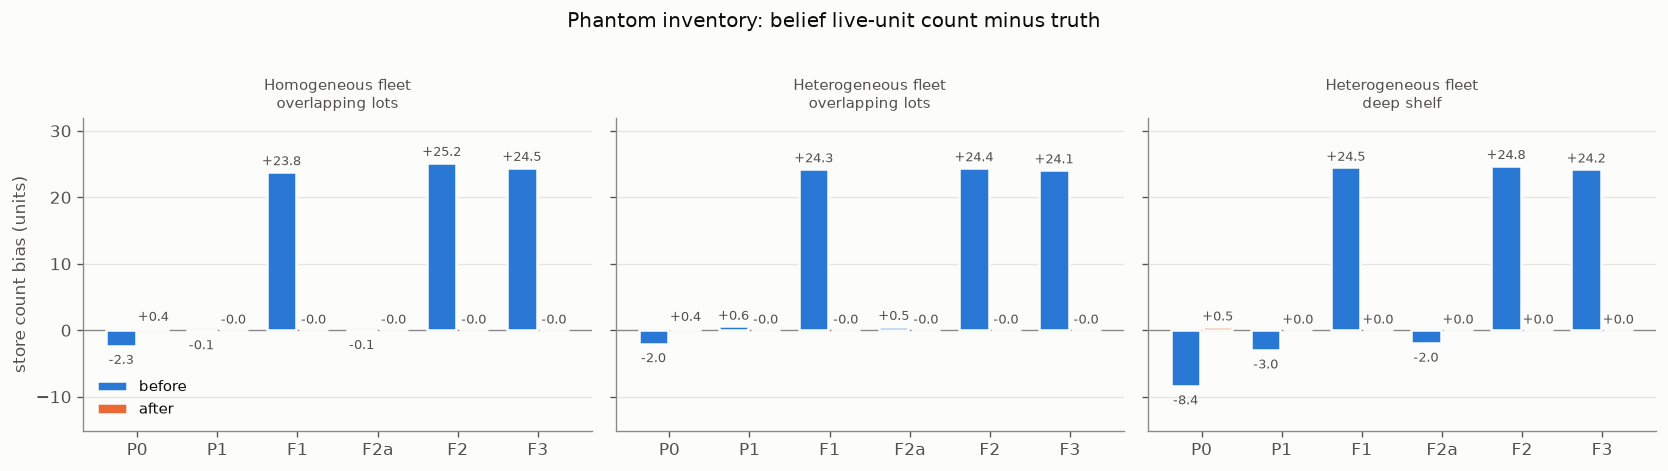

In [2]:
fig, axes = plt.subplots(1, len(SHARED), figsize=(14, 3.8), sharey=True)
for ax, regime in zip(axes, SHARED):
    b, a = pick(before, regime), pick(after, regime)
    grouped_bars(
        ax, RUNGS,
        {"before": [b[k]["count_bias"] for k in RUNGS],
         "after": [a[k]["count_bias"] for k in RUNGS]},
        [C_BEFORE, C_AFTER], fmt="{:+.1f}", legend=False,
    )
    ax.axhline(0, color=INK_3, linewidth=0.8, zorder=2)
    ax.set_title(regime.replace(", ", "\n"), fontsize=9, color=INK_2)
axes[0].set_ylabel("store count bias (units)")
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
fig.suptitle("Phantom inventory: belief live-unit count minus truth", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

After the fix the bias is **exactly zero** for every rung that observes spoilage (T-141 /
ADR 0143: independent per-unit decrements in truth, Poisson-binomial adapted proposal in
the filter, per-lot death draws under GSIN).

That is not a tuning result, it is conservation. With an empty shelf at day 0, observed
arrivals, observed sales, and a spoilage step that backward-samples **which units died**
to match the day's waste count, every particle satisfies

```
alive_t = alive_{t-1} - waste_t - sales_t + arrivals_t
```

exactly. P0 is the one rung left with count uncertainty, because it never sees waste — and
its residual is now honest posterior spread rather than a mechanical drain (see §5).

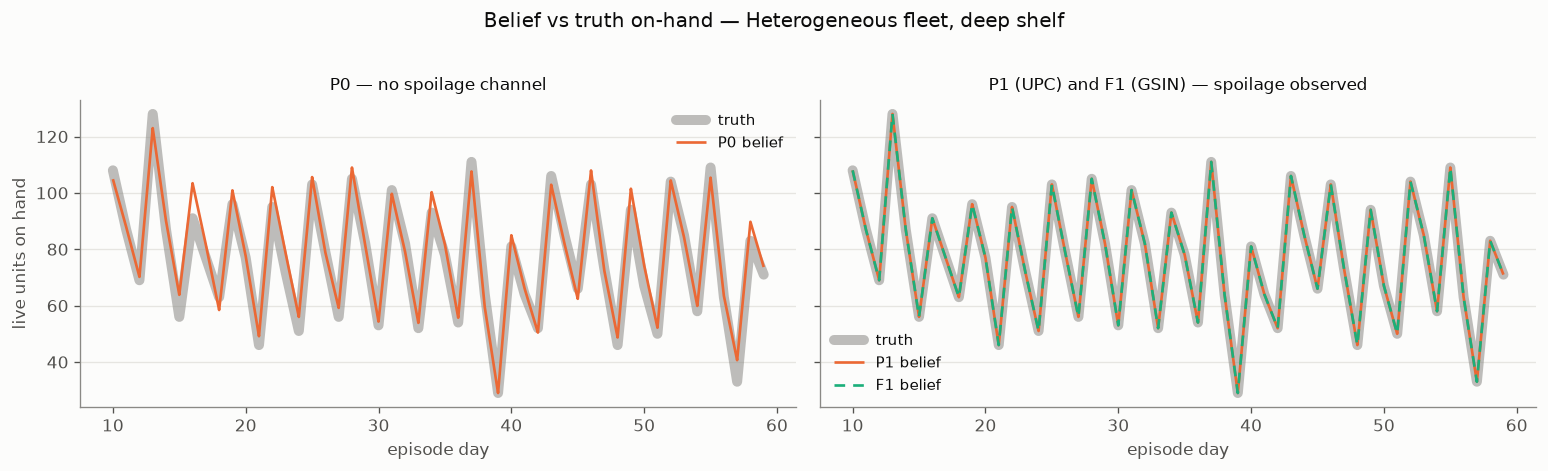

In [3]:
regime = DEEP  # the hardest case
a = pick(after, regime)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, rungs, title in [
    (axes[0], ["P0"], "P0 — no spoilage channel"),
    (axes[1], ["P1", "F1"], "P1 (UPC) and F1 (GSIN) — spoilage observed"),
]:
    s = a[rungs[0]]["series"]
    # Truth as a wide pale band: the lot-resolved beliefs land exactly on it, and a
    # thin line would simply be hidden underneath them.
    ax.plot(s["day"], s["truth_on_hand"], color=INK_3, linewidth=6, alpha=0.55,
            solid_capstyle="round", label="truth", zorder=2)
    for rung, color, dash in zip(rungs, [C_AFTER, C_THIRD], [(None, None), (4, 3)]):
        s = a[rung]["series"]
        ax.plot(s["day"], s["belief_on_hand"], color=color, linewidth=1.6,
                dashes=dash if dash[0] else (1, 0),
                label=f"{rung} belief", zorder=3 + rungs.index(rung))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("episode day")
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("live units on hand")
fig.suptitle(f"Belief vs truth on-hand — {regime}", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

P1 and F1 sit exactly on truth (the lines are indistinguishable). P0 traces a smooth
sawtooth through truth's lumpy one. The mechanism has moved twice: ADR 0141 made births
per-unit Gamma draws, so a delivery no longer shares one freshness, and ADR 0143 made
*aging* independent per unit, so a cohort no longer retires on one shared decrement either.
Truth is correspondingly smoother than it was, and P0 tracks it far better than in any
earlier epoch (§3) — but with no waste channel it still has to average over when spoilage
lands.

## 2. What GSIN actually buys, and at which scale

With the counts pinned, the honest comparison is *per lot*. Both channels observe the
delivery stream, so the bank's j-th-newest segment is truth's j-th-newest lot for either
one; the metrics below align on that. Only GSIN additionally learns which lot each sale and
each spoil came from.

**T-141 / ADR 0143.** Ground truth ages each live unit with an independent gamma draw;
the filter scores spoilage with an exact Poisson-binomial DP and backward-samples deaths
(per-lot under GSIN). Store `count_bias` is **0.000** on every spoilage rung across all
four diag regimes (24 rows).

This is the epoch where lot-resolved spoilage finally becomes **level**-informative, which
is exactly what ADR 0143 predicted. Under the shared-δ model a single latent decrement aged
every live unit identically, so per-lot waste counts could only falsify lot *ordering*;
with independent decrements the counts constrain per-unit death probabilities. Deep shelf,
`P1 → F1`, per-lot mean-f MAE:

| epoch | spoilage model | P1 (UPC) | F1 (GSIN) | GSIN gain |
|-------|----------------|----------|-----------|-----------|
| ADR 0137 | shared δ | 0.1291 | 0.1259 | 2.4% |
| T-140 / ADR 0141 | shared δ | 0.0891 | 0.0880 | 1.3% |
| **T-141 / ADR 0143** | **independent** | **0.0501** | **0.0366** | **26.9%** |

A one-to-two percent edge becomes a twenty-to-twenty-nine percent one across all four
regimes. Nothing about the *codes* changed between those rows — only what the physics lets
a lot-resolved waste count mean.

**T-140 / ADR 0141.** Pack date on the F2a/F2 rungs is **calendar transit duration**
(`receipt − pack` in days), not a rounded warped-τ surrogate. Epistemic width on that
channel comes from bootstrapping the fleet temperature factor φ̄, not a hand-set
`f2a_transit_sd`. Per-unit birth freshness is Gamma(k·Λ, θ) with shelf parameters — so
within-lot spread is aleatoric from the shelf law, not an extra dispersion knob.

The **F2 → F3** step (pack date → temperature trace) is **thermal-fleet dependent**: on an
isothermal homogeneous fleet, fixing Λ from the trace adds little over calendar pack date;
on `shipments_thermal()` (fixed duration, varying transit temperature), F3's exact Λ unlocks
the delivery-history gain the ladder is meant to price. The diag harness now includes a
*Thermal fleet, overlapping lots* regime alongside homogeneous and duration-heterogeneous
fixtures.

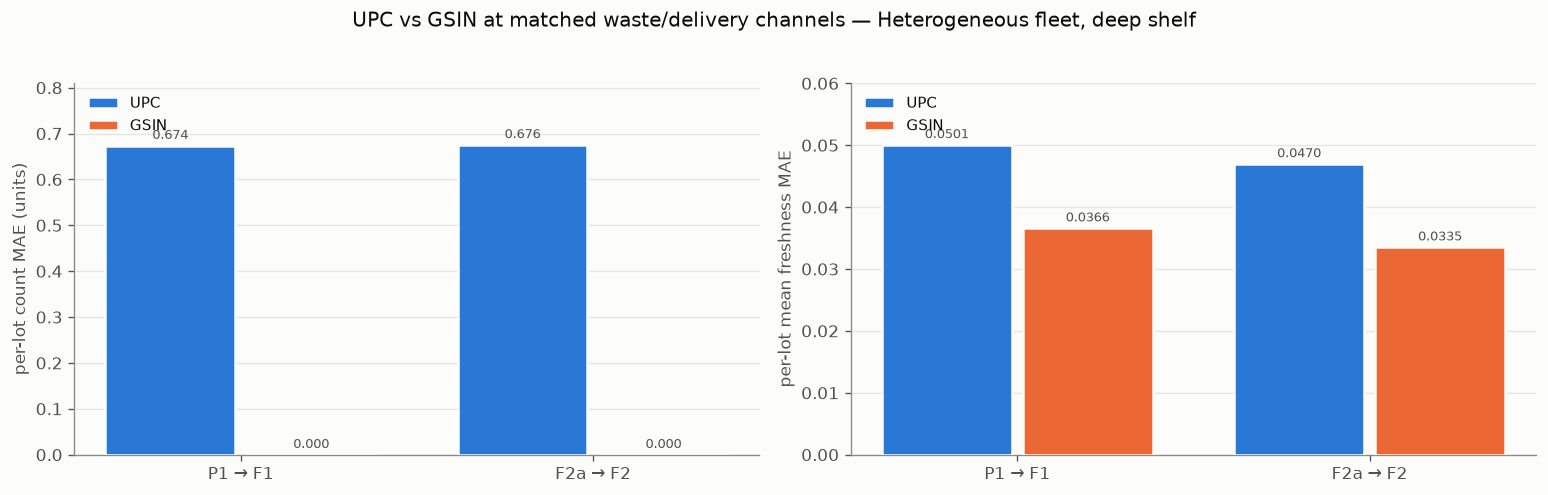

pair         metric                          UPC       GSIN
P1 → F1      lot_count_mae                0.6739     0.0000
P1 → F1      lot_mean_f_mae               0.0501     0.0366
P1 → F1      store_mean_f_mae             0.0195     0.0187
P1 → F1      eff_inv_mae                  1.3127     1.2734
P1 → F1      ess                        143.6920   110.2900
F2a → F2     lot_count_mae                0.6755     0.0000
F2a → F2     lot_mean_f_mae               0.0470     0.0335
F2a → F2     store_mean_f_mae             0.0159     0.0152
F2a → F2     eff_inv_mae                  1.1349     1.1034
F2a → F2     ess                        146.3680   113.1770


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
regime = DEEP
a = pick(after, regime)
pairs = [("P1", "F1"), ("F2a", "F2")]
labels = [f"{u} → {g}" for u, g in pairs]
for ax, key, ylab, fmt in [
    (axes[0], "lot_count_mae", "per-lot count MAE (units)", "{:.3f}"),
    (axes[1], "lot_mean_f_mae", "per-lot mean freshness MAE", "{:.4f}"),
]:
    grouped_bars(
        ax, labels,
        {"UPC": [a[u][key] for u, _ in pairs], "GSIN": [a[g][key] for _, g in pairs]},
        [C_BEFORE, C_AFTER], fmt=fmt, ylabel=ylab,
    )
fig.suptitle(f"UPC vs GSIN at matched waste/delivery channels — {regime}",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

print(f"{'pair':<12} {'metric':<24} {'UPC':>10} {'GSIN':>10}")
for u, g in pairs:
    for key in ("lot_count_mae", "lot_mean_f_mae", "store_mean_f_mae", "eff_inv_mae", "ess"):
        print(f"{u+' → '+g:<12} {key:<24} {a[u][key]:>10.4f} {a[g][key]:>10.4f}")

**Store count is exact under every spoilage rung** (`count_mae` and `count_bias` both
`0.000` for P1/F1/F2a/F2/F3): once sales and spoils are observed, the adapted PB proposal
removes exactly the right number of units. That is conservation, and both channels get it.

**Per-lot count is exact under GSIN and only under GSIN** (`0.000` vs `0.29–0.67` for UPC):
attributing sales and spoils to named lots makes each segment conserve the way the store
total does. This is the channel's most durable value — it has held at `0.000` in every
epoch since ADR 0137, and it is not a statistical result that better physics could erode.

The freshness *level* answer depends on which scale you ask about, and the two answers
differ by an order of magnitude:

- **At the store aggregate, lot codes buy 3–4%** — and that has not grown with the physics
  (6.0% at T-140, 4.0% at T-141 on the deep shelf). Picking is only weakly
  freshness-dependent (`sigma = 0.5`), so the cross-lot sales split is a weak signal about
  the store's *overall* freshness, and the store total already pins the count.
- **At the lot level, lot codes now buy 21–29%** (see the table above). Knowing which lot
  spoiled is informative about *that lot's* freshness, which is a question UPC cannot even
  pose.

*Store-level* freshness is bought by the **`delivery_history`** axis instead, which is
exactly the orthogonality ADR 0133 designs for: `code_type` resolves *where the stock is* —
and, since ADR 0143, how fresh each lot is — while `delivery_history` resolves how fresh the
shelf is overall.

## 2b. The delivery-history ladder is a variance decomposition

ADR 0141 made the pack-date channel honest — calendar transit duration with epistemic width
bootstrapped from the fleet's own temperature factor φ̄, replacing a rounded warped age
scored against a hand-set `f2a_transit_sd = 0.75`. Once it was honest, the ladder stopped
looking like a single ordered gain and started separating along the physics.

Each rung conditions on more of the transit segment, so each can only buy what the fleet
actually varies. Total variation against the truth freshness histogram is the metric to read
here: the ladder is about distribution *shape*, and TV is where that shows up.

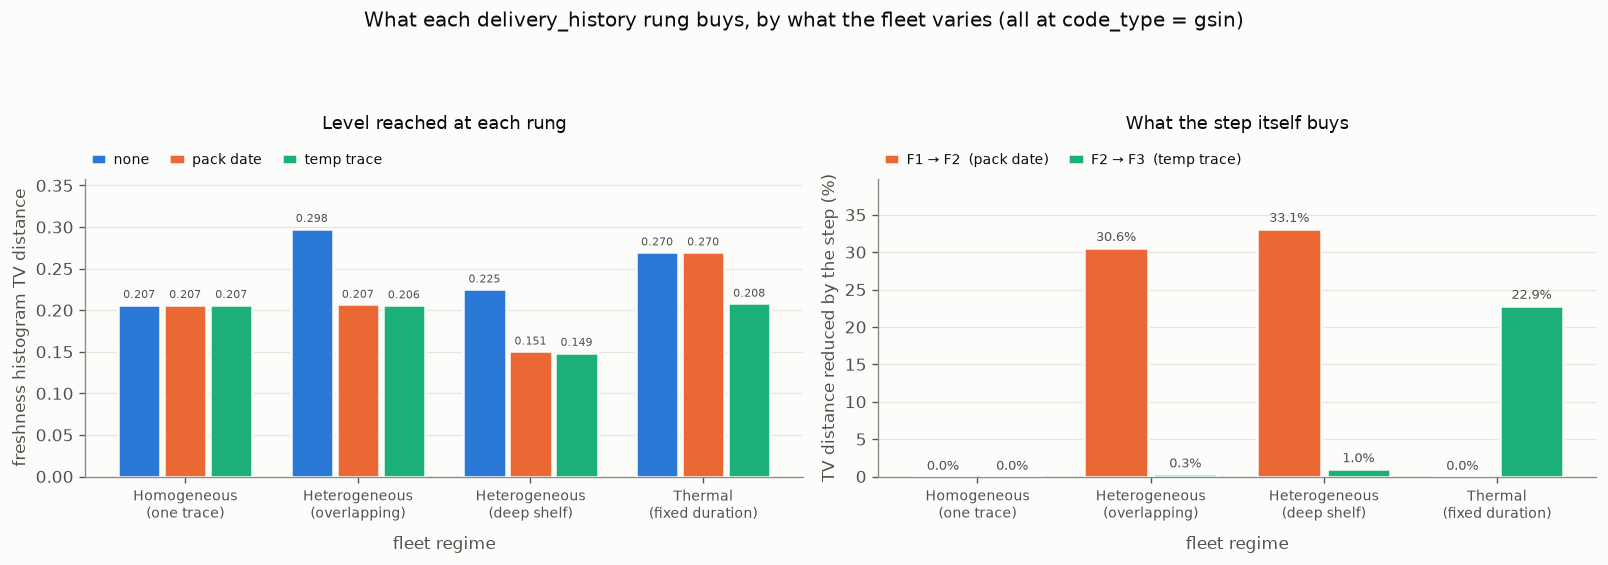

regime                                   F1→F2 (pack date)   F2→F3 (temp trace)
Homogeneous fleet, overlapping lots                   0.0%                 0.0%
Heterogeneous fleet, overlapping lots                30.6%                 0.3%
Heterogeneous fleet, deep shelf                      33.1%                 1.0%
Thermal fleet, overlapping lots                       0.0%                22.9%


In [5]:
LADDER = [("F1", "none"), ("F2", "pack date"), ("F3", "temp trace")]
SHORT = {
    HOMOG: "Homogeneous\n(one trace)",
    HET: "Heterogeneous\n(overlapping)",
    DEEP: "Heterogeneous\n(deep shelf)",
    THERMAL: "Thermal\n(fixed duration)",
}
tv = {r: [pick(after, r)[rung]["hist_tv"] for rung, _ in LADDER] for r in REGIMES}
labels = [SHORT[r] for r in REGIMES]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

# Left: the level each rung reaches. Right: the *step gain*, which is the claim —
# plotting the gain keeps a true zero baseline instead of truncating a bar axis to
# make a small difference in level visible.
grouped_bars(
    axes[0], labels,
    {lab: [tv[r][j] for r in REGIMES] for j, (_, lab) in enumerate(LADDER)},
    [C_BEFORE, C_AFTER, C_THIRD], fmt="{:.3f}",
    ylabel="freshness histogram TV distance", legend=False, label_size=6.6,
)
axes[0].set_title("Level reached at each rung", fontsize=10.5, pad=30)

grouped_bars(
    axes[1], labels,
    {"F1 → F2  (pack date)": [100 * (tv[r][0] - tv[r][1]) / tv[r][0] for r in REGIMES],
     "F2 → F3  (temp trace)": [100 * (tv[r][1] - tv[r][2]) / tv[r][1] for r in REGIMES]},
    [C_AFTER, C_THIRD], fmt="{:.1f}%", ylabel="TV distance reduced by the step (%)",
    legend=False, label_size=7.5,
)
axes[1].set_title("What the step itself buys", fontsize=10.5, pad=30)

# One legend per panel: the same two hues carry different meanings on the left
# (a rung) and the right (the step between two rungs), so a shared key would lie.
for ax, ncol in zip(axes, (3, 2)):
    ax.tick_params(axis="x", labelsize=8.5)
    ax.set_xlabel("fleet regime", labelpad=8)
    ax.legend(*ax.get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=ncol,
              loc="upper left", bbox_to_anchor=(-0.01, 1.13), handlelength=1.1,
              columnspacing=1.4, handletextpad=0.5)
fig.suptitle("What each delivery_history rung buys, by what the fleet varies "
             "(all at code_type = gsin)", y=1.06, fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

print(f"{'regime':<38} {'F1→F2 (pack date)':>19} {'F2→F3 (temp trace)':>20}")
for r in REGIMES:
    f1, f2, f3 = tv[r]
    print(f"{r:<38} {100 * (f1 - f2) / f1:>18.1f}% {100 * (f2 - f3) / f2:>19.1f}%")

The two steps are complementary rather than ordered: pack date does the work exactly where
transit *duration* varies, the temperature trace exactly where *temperature* varies, and
neither buys anything on a fleet that varies neither. That is the orthogonality claim ADR
0133 makes, and ADR 0141 is what finally made it measurable.

The practical consequence for the VOI story: **there is no fleet-independent price for
delivery history.** Quoting an F2 → F3 gain without saying what the fleet varies is quoting
a number that ranges from zero to the entire ladder.

## 3. Before and after, every metric

`lot_mean_f_mae` before the fix is dominated by the misalignment itself — the filter's
"lot 2" was not truth's lot 2 — so the before/after gap on the per-lot metrics measures the
bug, not a modelling improvement.

The *before* column is the T-137 pre-ADR-0137 run, three epochs back, and predates the
thermal fixture — so these panels cover the three shared regimes. §6 puts all four epochs
side by side, which is the more useful comparison now that the oldest one is mostly of
historical interest.

**P0 is the headline change here.** Independent per-unit aging did what a demand-censoring
term was supposed to do: store count MAE falls `19.10 → 2.76` and bias `+6.04 → +0.46` on
the deep shelf. When a cohort died in one lump, the sales-only constraint was nearly
uninformative about how much stock remained; when units die independently, the observed
sales stream pins the live count much harder. Open item 1 is largely closed as a
side effect — see §5.

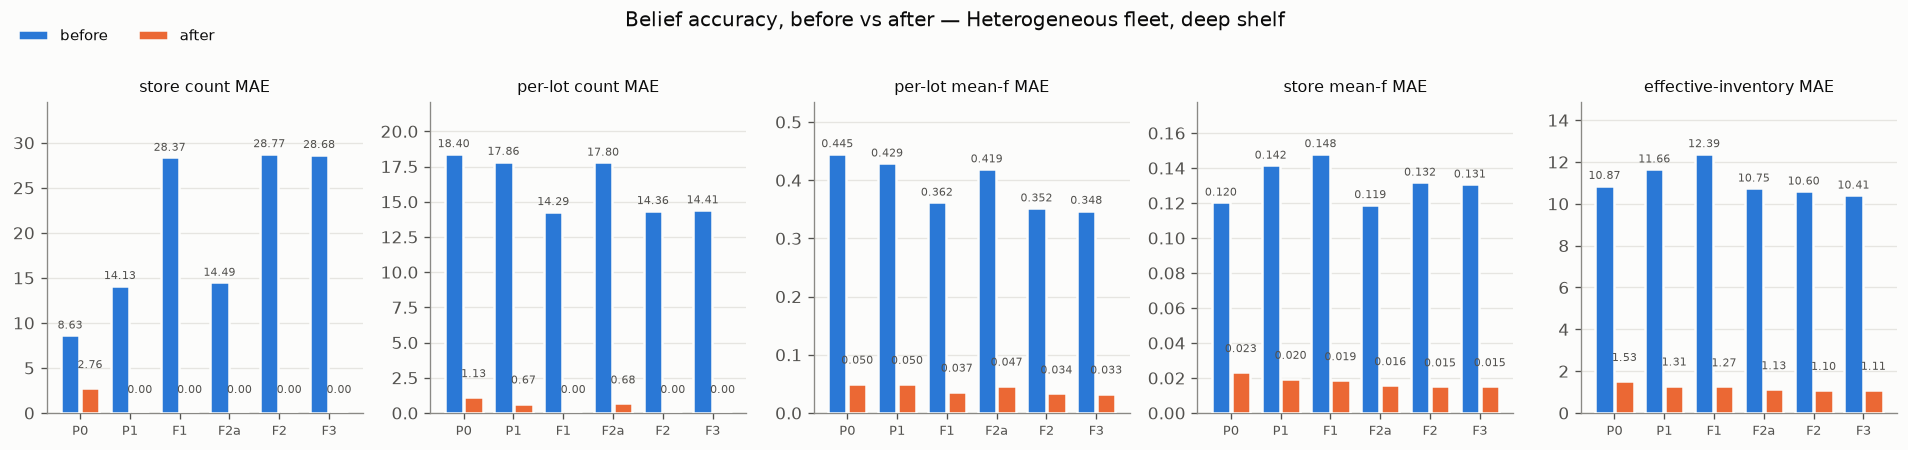

In [6]:
KEYS = [
    ("count_mae", "store count MAE", "{:.2f}"),
    ("lot_count_mae", "per-lot count MAE", "{:.2f}"),
    ("lot_mean_f_mae", "per-lot mean-f MAE", "{:.3f}"),
    ("store_mean_f_mae", "store mean-f MAE", "{:.3f}"),
    ("eff_inv_mae", "effective-inventory MAE", "{:.2f}"),
]
regime = DEEP
b, a = pick(before, regime), pick(after, regime)
fig, axes = plt.subplots(1, len(KEYS), figsize=(16, 3.6))
for ax, (key, title, fmt) in zip(axes, KEYS):
    grouped_bars(
        ax, RUNGS,
        {"before": [b[k][key] for k in RUNGS], "after": [a[k][key] for k in RUNGS]},
        [C_BEFORE, C_AFTER], fmt=fmt, legend=False, label_size=6.8, stagger=8.0,
    )
    ax.set_title(title, fontsize=9.5)
    ax.tick_params(axis="x", labelsize=8)
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, frameon=False, fontsize=9, ncol=2,
           loc="upper left", bbox_to_anchor=(0.005, 1.02))
fig.suptitle(f"Belief accuracy, before vs after — {regime}", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

## 4. The closed loop

Belief accuracy only matters if it survives into orders. The committed VOI CRN table on
this branch uses **damped survival-weighted base stock only** (`n_rollout_paths=0`) under
each mask on shared physics, and scores realised profit. That is the T-150 controller
setting: isolate filter accuracy from rollout variance.


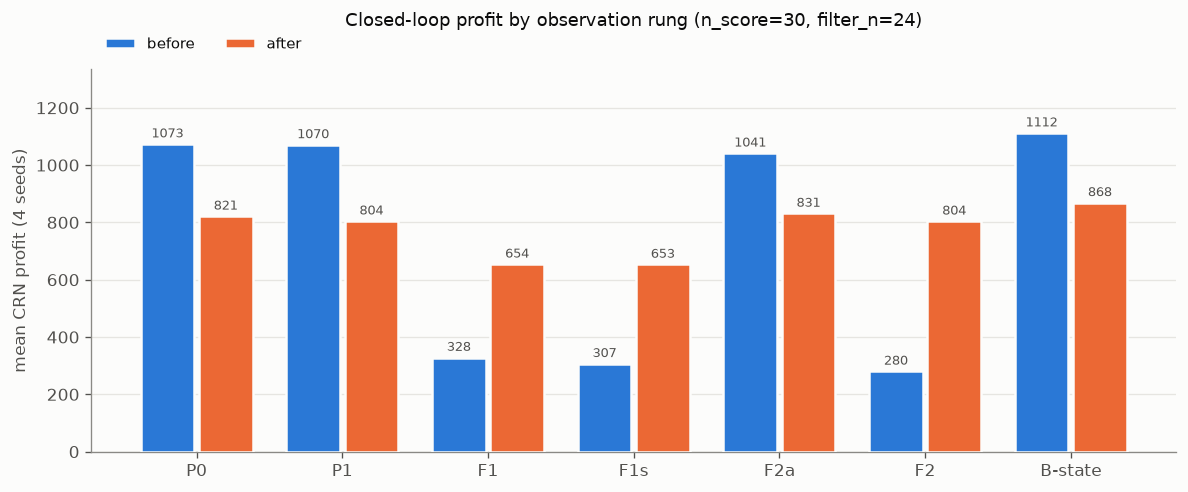

rung         before     after    change
P0           1073.2     821.4    -251.9
P1           1070.5     804.2    -266.2
F1            328.4     653.8    +325.4
F1s           306.8     653.1    +346.4
F2a          1041.4     831.2    -210.1
F2            280.2     803.9    +523.6
B-state      1111.8     868.4    -243.4


In [7]:
SCEN = ["P0", "P1", "F1", "F1s", "F2a", "F2", "B-state"]


def mean_profit(rows):
    out = {}
    for s in SCEN:
        vals = [r["profit"] for r in rows if r["scenario"] == s]
        out[s] = float(np.mean(vals))
    return out


pb, pa = mean_profit(voi_before), mean_profit(voi_after)
fig, ax = plt.subplots(figsize=(10, 4.2))
grouped_bars(
    ax, SCEN,
    {"before": [pb[s] for s in SCEN], "after": [pa[s] for s in SCEN]},
    [C_BEFORE, C_AFTER], fmt="{:.0f}", ylabel="mean CRN profit (4 seeds)", legend=False,
)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left",
          bbox_to_anchor=(0.0, 1.01))
ax.set_title("Closed-loop profit by observation rung (n_score=30, filter_n=24)",
             fontsize=11, pad=26)
fig.tight_layout()
plt.show()

print(f"{'rung':<9} {'before':>9} {'after':>9} {'change':>9}")
for s in SCEN:
    print(f"{s:<9} {pb[s]:>9.1f} {pa[s]:>9.1f} {pa[s] - pb[s]:>+9.1f}")

Before the GSIN likelihood fix, lot-tracked rungs earned roughly **a third** of the books-only
rungs' profit — a filter running blind produces a belief the controller cannot use.

**Current behaviour (T-150, damped base-stock, four seeds).** Mean scored profit is about
821 (P0), 804 (P1), 654 (F1 / F1s), 831 (F2a), 804 (F2), and 868 for the `B-state` oracle.
Seed-to-seed spread is large (one seed lands far below the others). Pack-date F2a is the
best filter rung on this table; lot-code rungs without pack date are the worst. That is a
property of this policy and these four seeds, not a proof that more data always pays.

The GSIN/UPC diagnostic JSON in §1–§3 was **not** regenerated in T-150 (a 17-minute job
the ticket did not need). Those panels still describe the T-141 spoilage-likelihood epoch.
The arrival-ladder claim for *this* ticket lives in notebook 13 (Modal, T-150 wheel).

## 5. Cost, and what is left


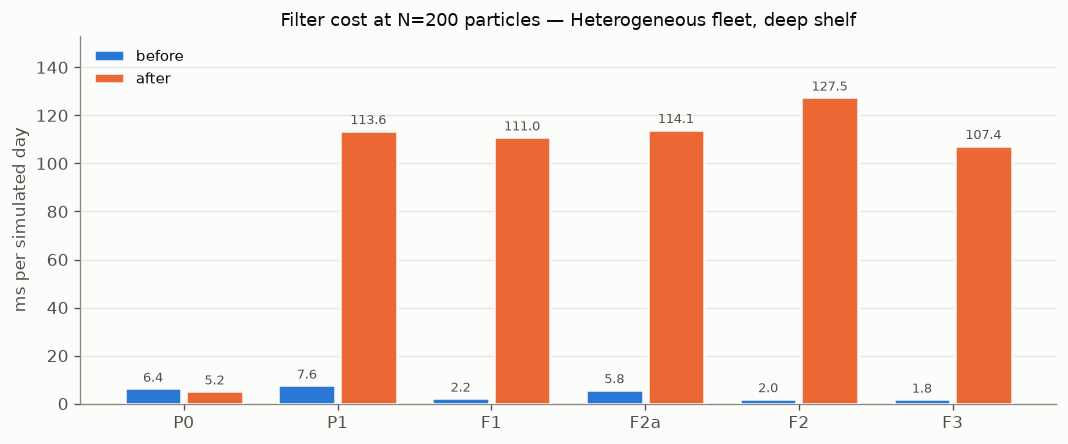

In [8]:
regime = DEEP
b, a = pick(before, regime), pick(after, regime)
fig, ax = plt.subplots(figsize=(9, 3.8))
grouped_bars(
    ax, RUNGS,
    {"before": [b[k]["ms_per_day"] for k in RUNGS],
     "after": [a[k]["ms_per_day"] for k in RUNGS]},
    [C_BEFORE, C_AFTER], fmt="{:.1f}", ylabel="ms per simulated day",
)
ax.set_title(f"Filter cost at N=200 particles — {regime}", fontsize=11)
fig.tight_layout()
plt.show()

Runtime rises to **~50–130 ms/day** at N=200 on the PB filter path, against roughly
**5 ms** in every earlier epoch — a **20×** increase. It is still inside the 500 ms studio
budget, but the margin is now one order of magnitude rather than two, and the deep-shelf
rungs (108–128 ms) are the ones to watch as `L` grows. Each spoilage day runs a
Poisson-binomial DP plus truncated-gamma survivors instead of short-circuiting on a shared
δ. P0 is unaffected (~5 ms) because it never observes waste.

One practical consequence outside the notebook: `gsin_upc_ac12` shells out to this
diagnostic, so the regression gate is now a ~17 minute release run. Both of its tests share
a single invocation rather than spawning it twice.

## 6. Four epochs of the same question

The study has now been run at four code tips. It is worth putting them side by side,
because the absolute numbers moved by more than an order of magnitude while the thing the
notebook is actually about — *what lot codes buy* — barely moved at all.

Only the three regimes present in every file are charted; the thermal fixture arrives at
T-140.

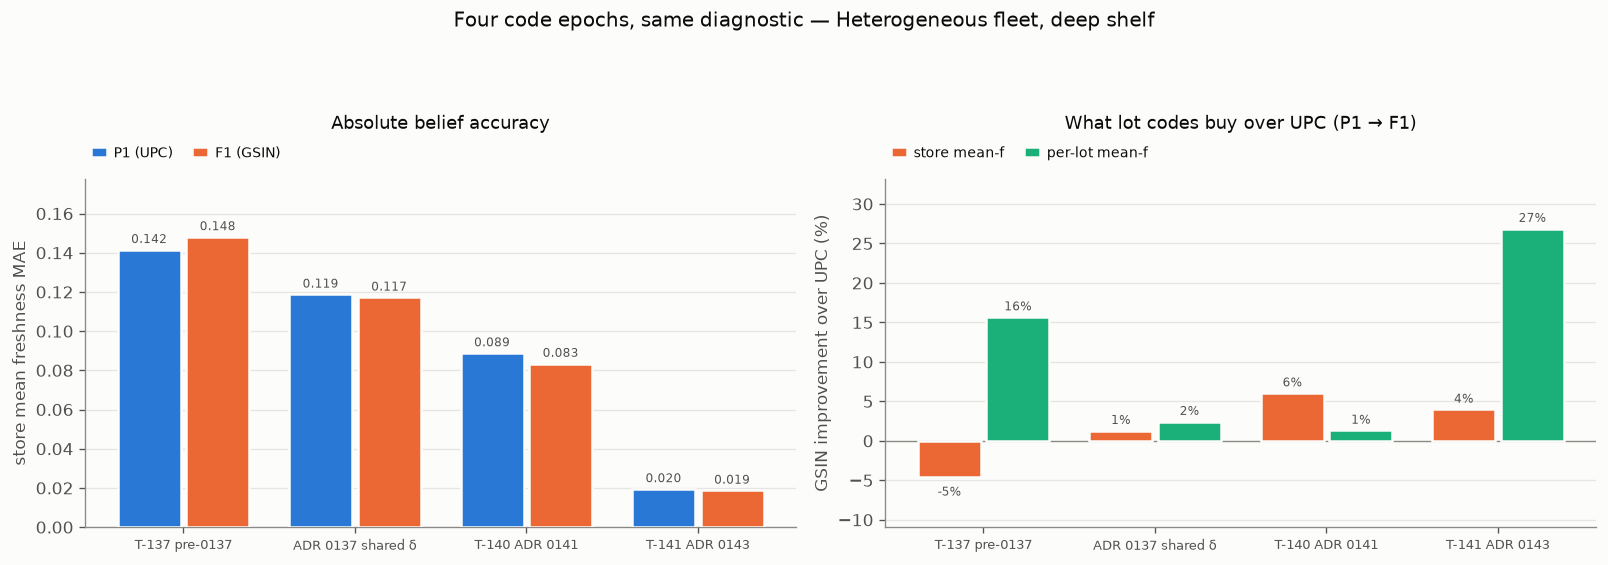

epoch                           store mean-f        per-lot mean-f         per-lot count   ms/day
                             P1 → F1  (gain)       P1 → F1  (gain)               P1 → F1       F1
-------------------------------------------------------------------------------------------------
T-137 pre-0137          0.1416 →  0.1481   -5%  0.4292 →  0.3619  +16% 17.8570 → 14.2902  +20%      2.2
ADR 0137 shared δ       0.1188 →  0.1173   +1%  0.1291 →  0.1259   +2%  0.4434 →  0.0000 +100%      6.3
T-140 ADR 0141          0.0888 →  0.0835   +6%  0.0891 →  0.0880   +1%  0.6337 →  0.0000 +100%      5.2
T-141 ADR 0143          0.0195 →  0.0187   +4%  0.0501 →  0.0366  +27%  0.6739 →  0.0000 +100%    111.0


In [9]:
EPOCH_KEYS = list(EPOCHS)
regime = DEEP


def epoch_series(rung, key):
    return [pick(rows, regime).get(rung, {}).get(key, float("nan"))
            for rows in EPOCHS.values()]


fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

grouped_bars(
    axes[0], [e.replace("\n", " ") for e in EPOCH_KEYS],
    {"P1 (UPC)": epoch_series("P1", "store_mean_f_mae"),
     "F1 (GSIN)": epoch_series("F1", "store_mean_f_mae")},
    [C_BEFORE, C_AFTER], fmt="{:.3f}", ylabel="store mean freshness MAE", legend=False,
    label_size=7.0,
)
axes[0].set_title("Absolute belief accuracy", fontsize=10.5, pad=30)

gain = []
for rows in EPOCHS.values():
    a = pick(rows, regime)
    u, g = a["P1"]["store_mean_f_mae"], a["F1"]["store_mean_f_mae"]
    gain.append(100 * (u - g) / u if u else float("nan"))
gain_lot = []
for rows in EPOCHS.values():
    a = pick(rows, regime)
    u, g = a["P1"]["lot_mean_f_mae"], a["F1"]["lot_mean_f_mae"]
    gain_lot.append(100 * (u - g) / u if u else float("nan"))

grouped_bars(
    axes[1], [e.replace("\n", " ") for e in EPOCH_KEYS],
    {"store mean-f": gain, "per-lot mean-f": gain_lot},
    [C_AFTER, C_THIRD], fmt="{:.0f}%", ylabel="GSIN improvement over UPC (%)",
    legend=False, label_size=7.0,
)
axes[1].axhline(0, color=INK_3, linewidth=0.8, zorder=2)
axes[1].set_title("What lot codes buy over UPC (P1 → F1)", fontsize=10.5, pad=30)

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(*ax.get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=2,
              loc="upper left", bbox_to_anchor=(-0.01, 1.13), handlelength=1.1,
              columnspacing=1.4, handletextpad=0.5)
fig.suptitle(f"Four code epochs, same diagnostic — {regime}", y=1.06, fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

hdr = (f"{'epoch':<22}{'store mean-f':>22}{'per-lot mean-f':>22}"
       f"{'per-lot count':>22}{'ms/day':>9}")
print(hdr)
print(f"{'':<22}{'P1 → F1  (gain)':>22}{'P1 → F1  (gain)':>22}{'P1 → F1':>22}{'F1':>9}")
print("-" * len(hdr))
for name, rows in EPOCHS.items():
    a = pick(rows, regime)
    cells = ""
    for k in ("store_mean_f_mae", "lot_mean_f_mae", "lot_count_mae"):
        u, g = a["P1"][k], a["F1"][k]
        pct = f"{100 * (u - g) / u:+.0f}%" if u else "  -"
        cells += f"{u:>8.4f} →{g:>8.4f}{pct:>6}"
    print(f"{name.replace(chr(10), ' '):<22}{cells}{a['F1']['ms_per_day']:>9.1f}")

Three readings, in order of how much they should change anyone's mind.

**1. Absolute belief accuracy improved by an order of magnitude, and almost none of it came
from lot codes.** Store mean-f MAE on the deep shelf went `0.148 → 0.117 → 0.084 → 0.019`
across the four epochs. Effective-inventory MAE — the number the controller actually sees —
went `12.4 → 8.3 → 6.1 → 1.27`. Those are large, real gains, and they accrued to the UPC
rungs and the GSIN rungs in almost equal measure. They were bought by fixing the *physics
and the likelihood*, not by adding data.

**2. What lot codes buy has stayed remarkably stable, except once.** The `P1 → F1` store
mean-f gain is 1.3% / 6.0% / 4.0% at the last three epochs — small, and not trending up.
Per-lot count has been exact under GSIN and only under GSIN since ADR 0137. The single real
movement is per-lot *freshness*, which jumped from ~1–2% to 21–29% at T-141, because
independent per-unit aging is what makes a lot-resolved waste count mean something about
that lot's freshness rather than merely about lot ordering.

**3. The oldest column is archaeology, and its per-lot numbers should not be read at all.**
`T-137 pre-0137` is the era when the GSIN likelihood returned `-inf` and the filter ran
blind. Its store metrics are honestly bad (GSIN 5% *worse* than UPC). Its per-lot metrics
look like GSIN wins — `+16%` on mean-f, `+20%` on count — but both channels were carrying
tens of units of phantom mass on partitions that did not correspond to truth's lots, so
those percentages are two wrong numbers dividing into each other, not a gain.

That is the second time this study has been misled by a measurement rather than a model:
the T-138 harness regression did the same thing to the per-lot columns at T-141, and it is
the reason the shipped T-141 notebook concluded that per-lot accuracy had *regressed* (see
the harness note at the top). Both failures were silent, both looked like findings, and
both survived a review. It is worth assuming there is a third.

### Open items

1. **P0 count bias — largely closed by ADR 0143, not by the intended fix.** The bias is
   down to `+0.37 … +0.46` units from `+6.0 … +10.1`, and count MAE to `1.4–2.8` from
   `19.1`. The original diagnosis still stands in principle — P0's sales constraint is
   one-sided (`alive >= sales`), so over-stocked particles are never *directly* penalised —
   but independent per-unit aging made the sales stream itself far more informative about
   the live count, which absorbed most of the error. A demand-censoring term (score
   `P(D >= sales)` rather than `P(D = sales)` on stockout, needing the calendar day threaded
   into `filter_step_unit`) is now a refinement rather than a correction.
2. **Cross-lot allocation is multinomial, not Wallenius.** Deliberate first-order
   approximation (ADR 0135), validated at small and realistic lot counts. It matters little
   here because `sigma = 0.5` makes the signal weak either way.
3. **VOI monotonicity** — see the caveat in §4. Policy/cost issue, not a filter issue, and
   now the binding constraint on this whole line of work: three epochs of belief-accuracy
   improvement have produced no profit ordering.
4. **ESS falls under GSIN** (`110` vs `144` at P1 on the deep shelf, N=200). This is the
   expected signature of a sharper likelihood concentrating weight, not a defect — but it
   means the non-regression guard cannot ask for `F1.ess >= P1.ess`. `gsin_upc_ac12` now
   asserts an ESS *floor* per rung instead, plus per-lot count exactness under GSIN.
5. **Cost headroom.** 20× runtime for the PB path (§5). Fine at `N=200, L=10`; worth a
   budget check before raising either.
*Closed since this notebook was written:* the legacy binomial waste primitives
(`p1_totals_loglik`, `loglik_waste_by_units`, `loglik_waste_tot_after_sales_by`, and the
`binom_pmf` / `iter_compositions` helpers only they used) have been **deleted** from
`unit_ll` rather than left exported as research-only. Leaving a
`Binomial(waste; rem, dead/units)` on the public surface is a standing invitation to rewire
the filter onto a waste model the shared-decrement physics does not support. The acceptance
tests that pinned them were re-pointed at the surviving terms — the contract they protect
(*every weight term is deterministic; randomness lives only in the proposal*) is unchanged.
See ADR 0137 §4.